#### Problem Statement

The objective is to analyze and identify the key factors that influence graduate admissions.

By leveraging machine learning models, we aim to:
- Determine which factors contribute most significantly to the admission decision.
- Understand how these factors are interrelated.
- Develop a predictive model that estimates an applicant’s probability of admission based on their profile.

This analysis will help Jamboree provide data-driven guidance to students on improving their chances of securing admission into graduate programs.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Jamboree/data/Jamboree_Admission.csv")

df_original = df.copy()

df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.shape

(500, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [7]:
# dropping the serial number index column
df = df.drop(columns = ['Serial No.'])
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

In [8]:
# checking missing values in the dataframe
df.isna().sum()

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [9]:
# checking the unique values
df.nunique()

GRE Score             49
TOEFL Score           29
University Rating      5
SOP                    9
LOR                    9
CGPA                 184
Research               2
Chance of Admit       61
dtype: int64

##### Summary:

- Continuous → GRE, TOEFL, SOP, LOR, CGPA, Chance of Admit
- Categorical → University Rating, Research

In [10]:
# removing leading and trailing spaces from the column names. LOR had the leading space
df.columns = df.columns.str.strip()

#### Exploratory Data Analysis

##### Univariate Analysis

In [12]:
# checking the distribution of the categorical columns
categorical_cols = ['University Rating','Research']

for column in categorical_cols:
    print(f"Value counts for column: {column}")
    print(df[column].value_counts())
    print("\n" + "-"*50 + "\n")

Value counts for column: University Rating
University Rating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64

--------------------------------------------------

Value counts for column: Research
Research
1    280
0    220
Name: count, dtype: int64

--------------------------------------------------



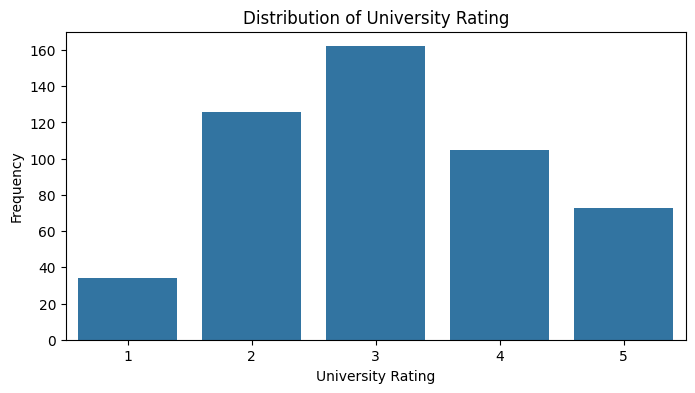

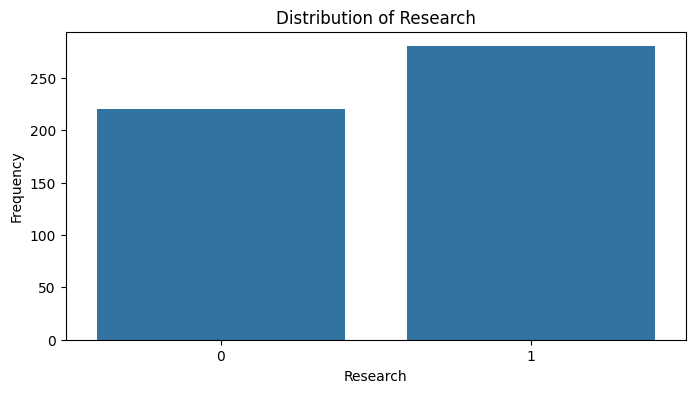

In [13]:
# using countplot to visualise the distribution of categorical variables
for column in categorical_cols:
    plt.figure(figsize = (8,4))
    sns.countplot(x = df[column])
    plt.title(f"Distribution of {column}")
    plt.ylabel("Frequency")
    plt.xlabel(column)
    plt.show()

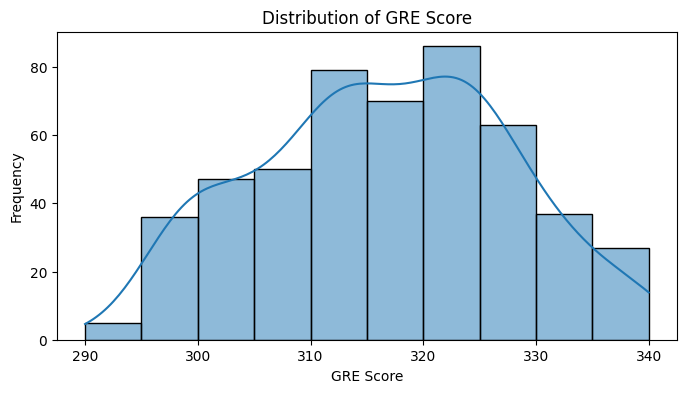

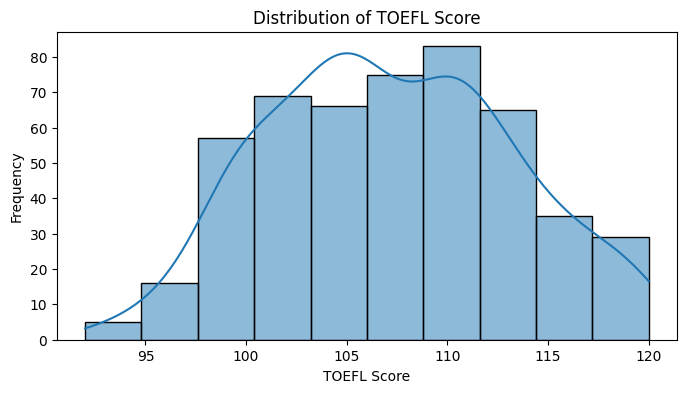

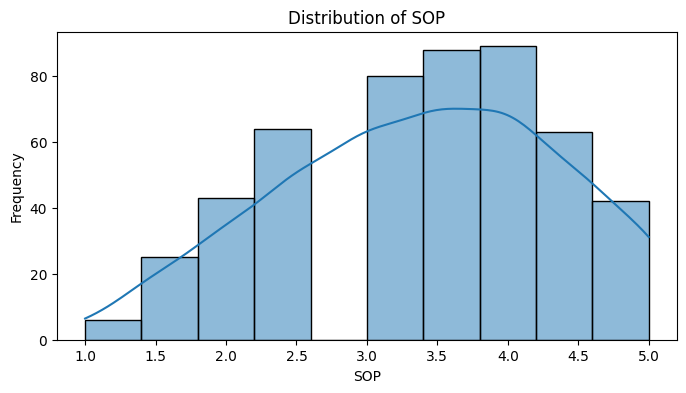

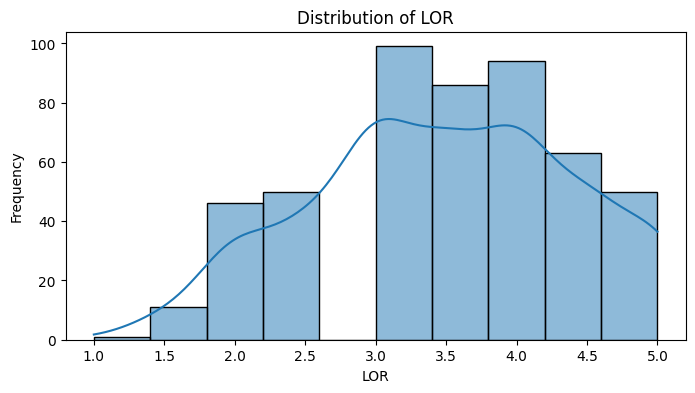

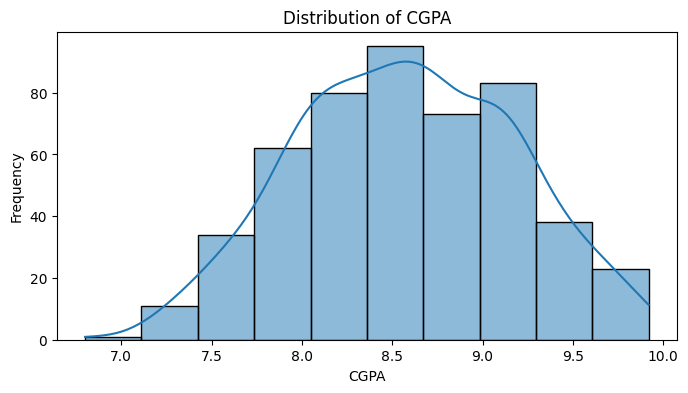

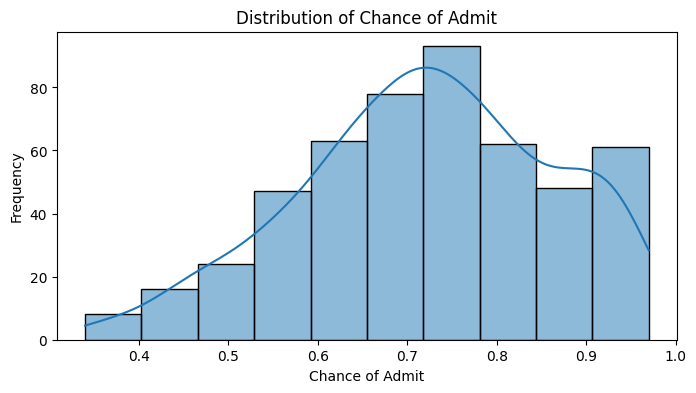

In [17]:
# checking the distribution of the numerical columns
numerical_cols = ['GRE Score','TOEFL Score','SOP','LOR','CGPA','Chance of Admit']

for column in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[column], kde=True, bins=10)
    plt.title(f"Distribution of {column}")
    plt.ylabel("Frequency")
    plt.show()

In [18]:
# Summary statistics of the dataframe
df.describe().round(2)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,316.47,107.19,3.11,3.37,3.48,8.58,0.56,0.72
std,11.30,6.08,1.14,0.99,0.93,0.60,0.50,0.14
min,290.00,92.00,1.00,1.00,1.00,6.80,0.00,0.34
25%,308.00,103.00,2.00,2.50,3.00,8.13,0.00,0.63
50%,317.00,107.00,3.00,3.50,3.50,8.56,1.00,0.72
75%,325.00,112.00,4.00,4.00,4.00,9.04,1.00,0.82
max,340.00,120.00,5.00,5.00,5.00,9.92,1.00,0.97


##### Summarized Insights
- GRE & TOEFL: Scores are tightly clustered around the mean (GRE ≈ 316, TOEFL ≈ 107) with low variability, indicating most applicants perform well academically.
- University Rating, SOP & LOR: Majority fall in the mid-range (2–4), suggesting average-to-good ratings are common.
- CGPA: High overall (mean ≈ 8.6), with most students having strong academic records.
- Research: ~56% of applicants have research experience, making it an important differentiator.
- Chance of Admit: Centered around 0.72, with most applicants having a moderate-to-high probability of admission.

##### Key Takeaways
- Academic scores are strong for most applicants → less variance in GRE/TOEFL/CGPA.
- Qualitative factors (SOP, LOR, Research, University Rating) likely play a bigger role in distinguishing candidates.
- Dataset leans toward well-qualified applicants, so predictions will be more relevant for competitive profiles.

##### Bivariate Analysis

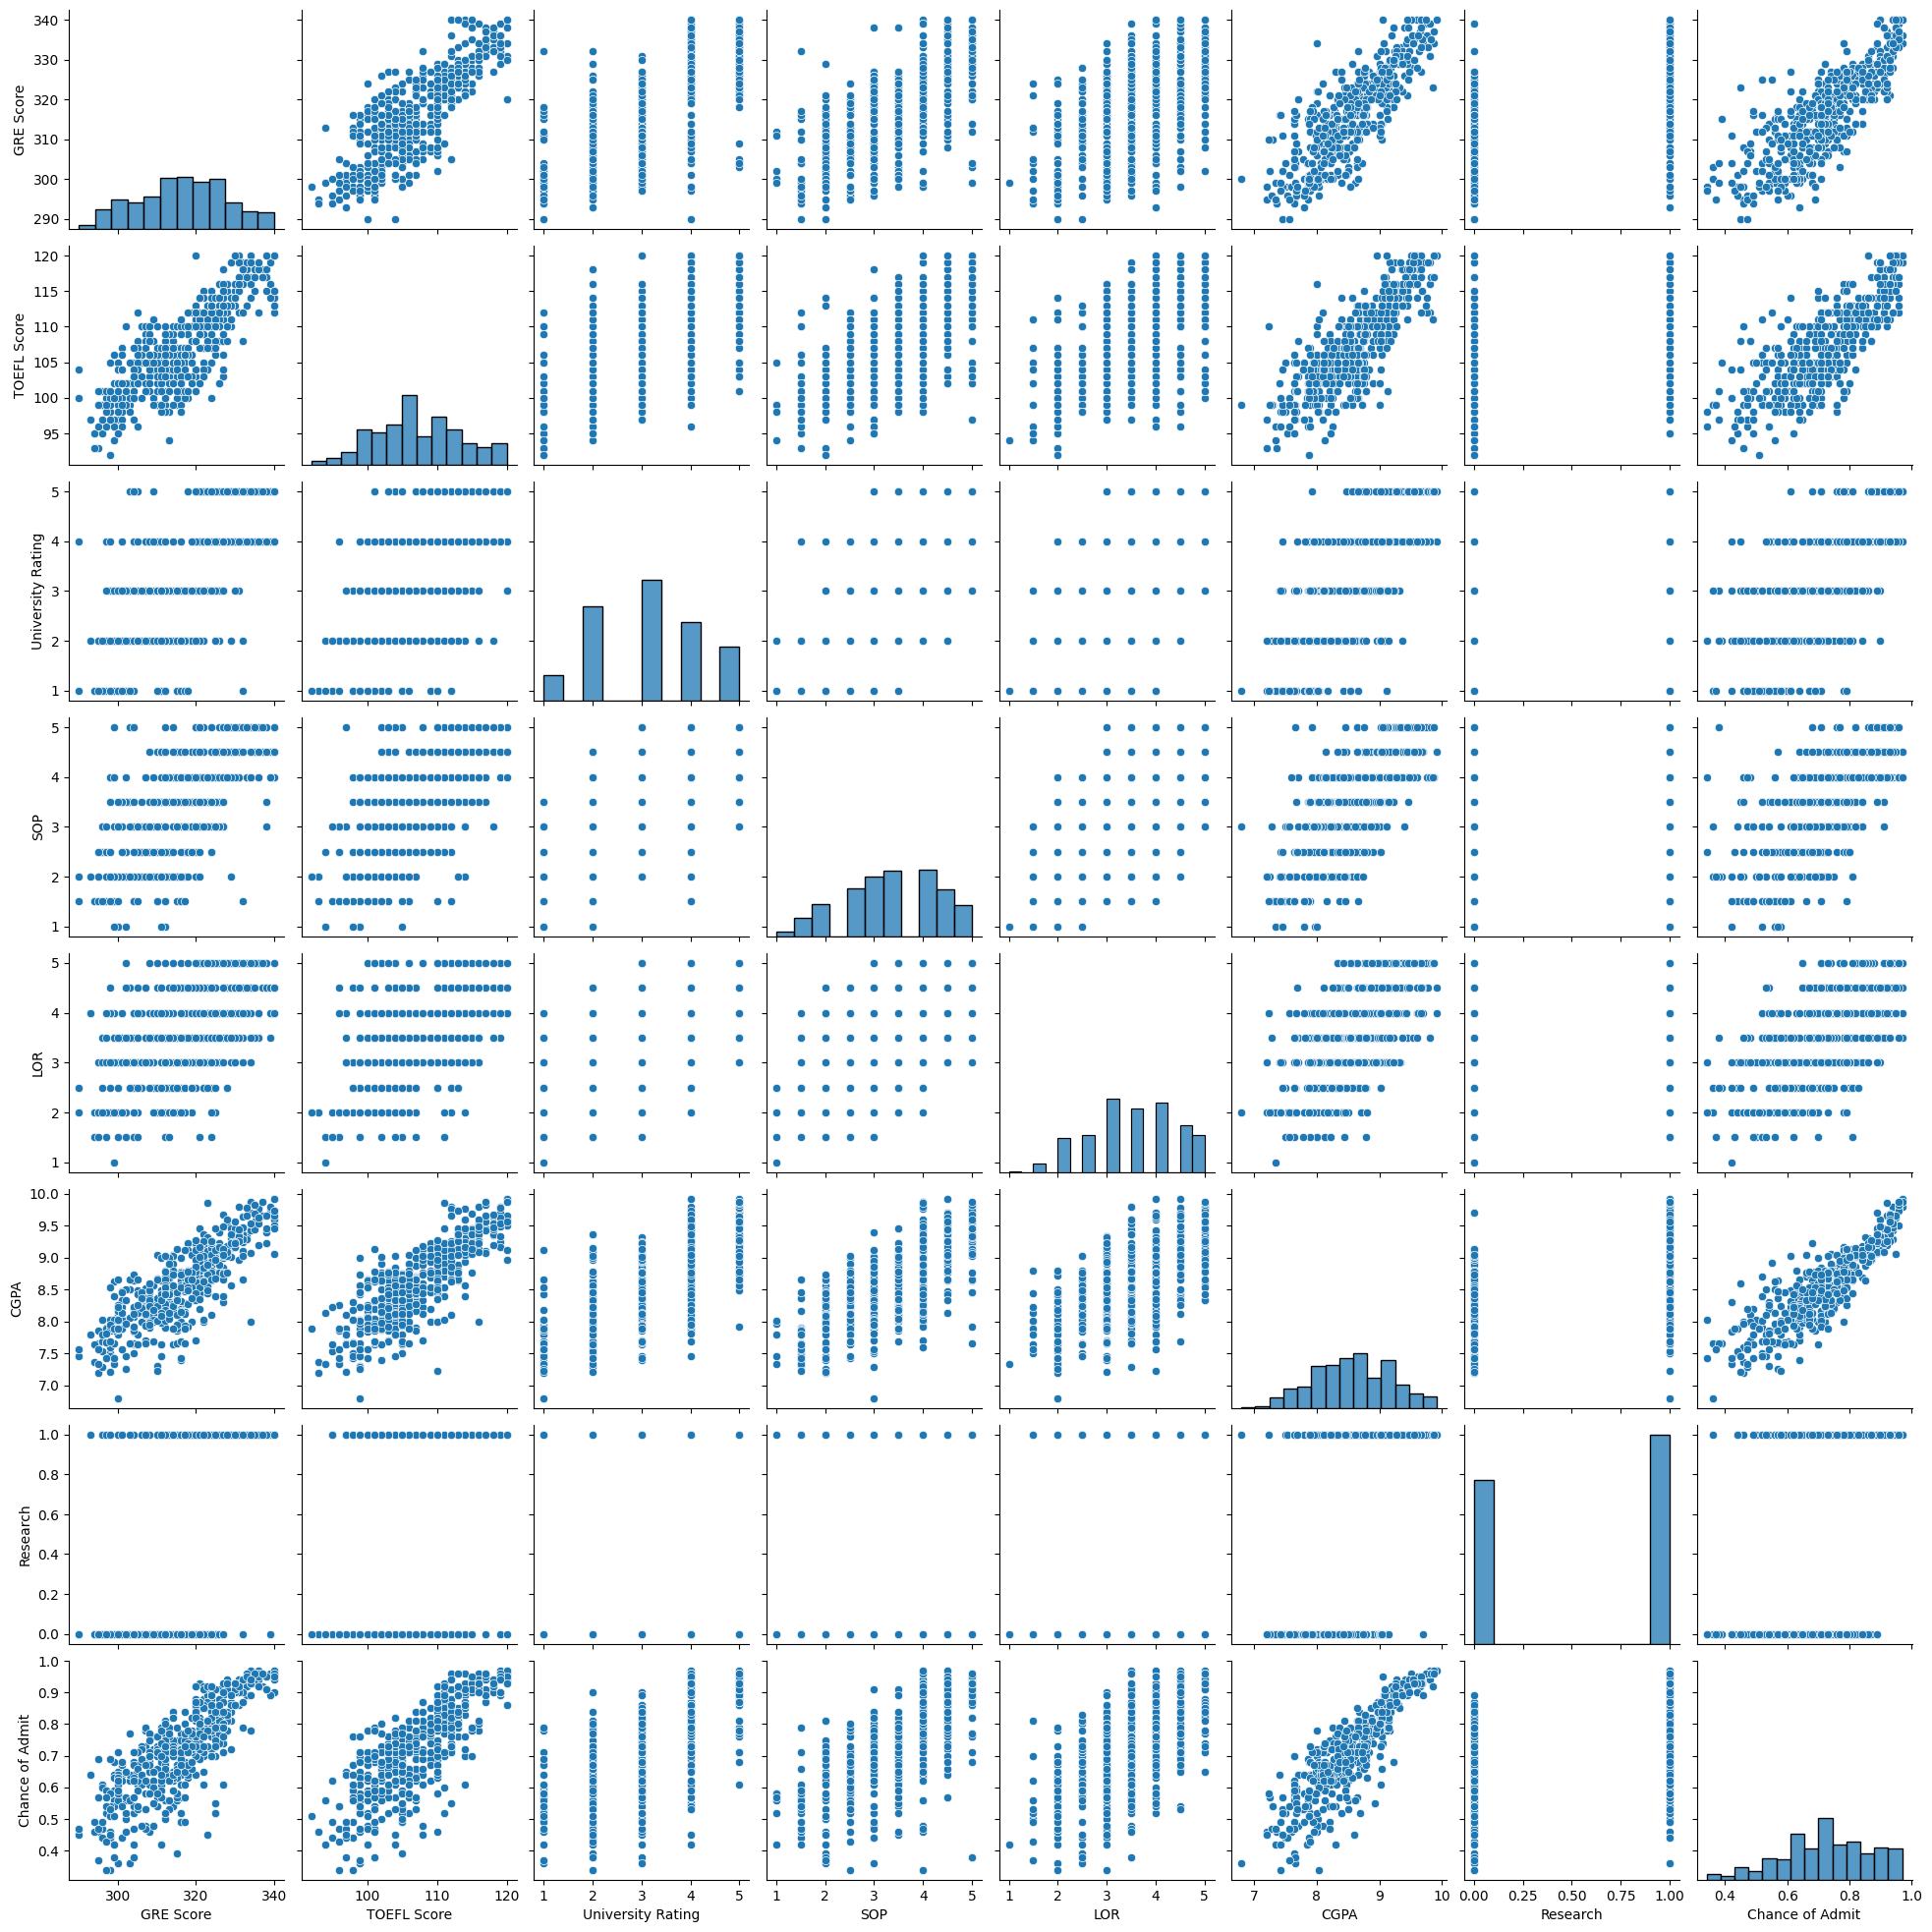

In [19]:
# checking the distribution between the features using pairplot
sns.pairplot(df)

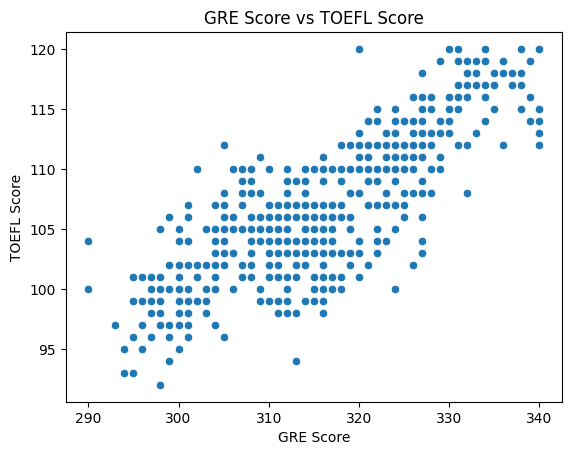

In [20]:
# GRE Score Vs TOFEL
sns.scatterplot(data=df, x='GRE Score', y='TOEFL Score')
plt.title("GRE Score vs TOEFL Score")
plt.xlabel("GRE Score")
plt.ylabel("TOEFL Score")
plt.show()

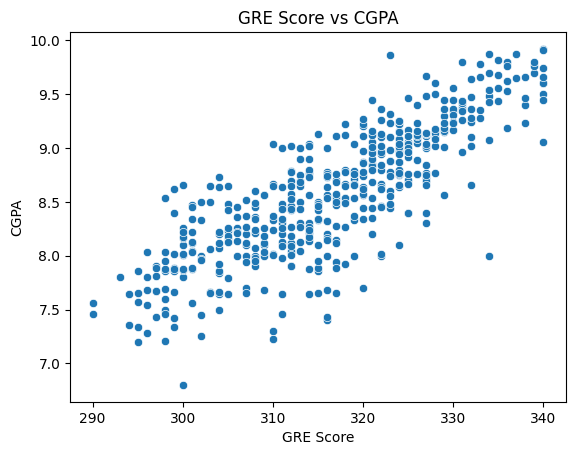

In [21]:
# GRE Score Vs CGPA
sns.scatterplot(data=df, x='GRE Score', y='CGPA')
plt.title("GRE Score vs CGPA")
plt.xlabel("GRE Score")
plt.ylabel("CGPA")
plt.show()

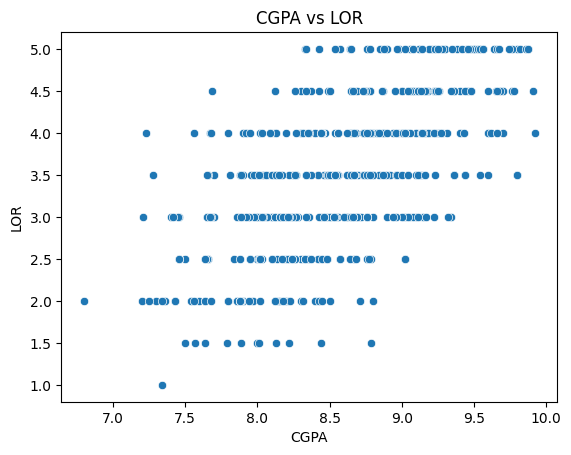

In [22]:
# CGPA Vs LOR
sns.scatterplot(data=df, x='CGPA', y='LOR')
plt.title("CGPA vs LOR")
plt.xlabel("CGPA")
plt.ylabel("LOR")
plt.show()

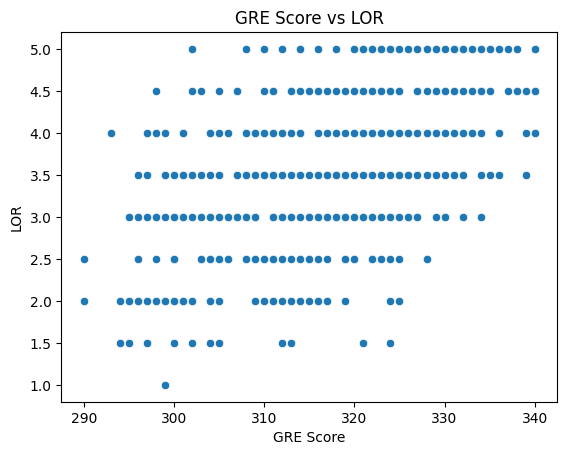

In [23]:
# GRE Score Vs LOR
sns.scatterplot(data=df, x='GRE Score', y='LOR')
plt.title("GRE Score vs LOR")
plt.xlabel("GRE Score")
plt.ylabel("LOR")
plt.show()

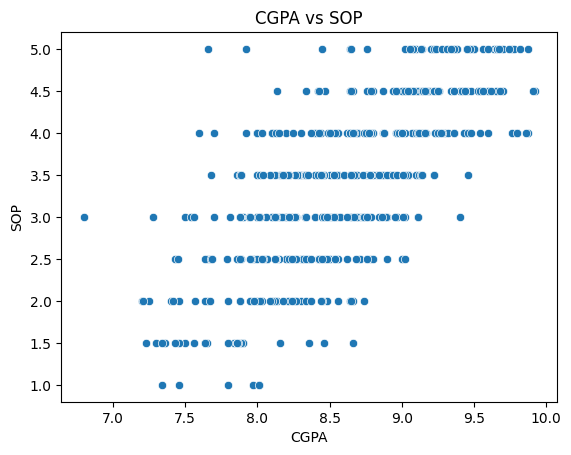

In [24]:
# CGPA Vs SOP
sns.scatterplot(data=df, x='CGPA', y='SOP')
plt.title("CGPA vs SOP")
plt.xlabel("CGPA")
plt.ylabel("SOP")
plt.show()

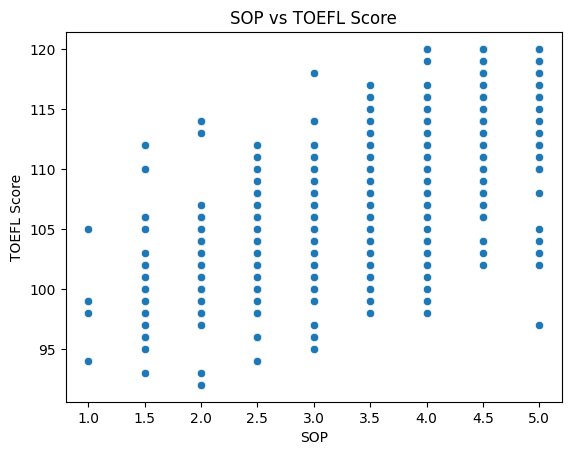

In [25]:
# SOP Vs TOFEL
sns.scatterplot(data=df, x='SOP', y='TOEFL Score')
plt.title("SOP vs TOEFL Score")
plt.xlabel("SOP")
plt.ylabel("TOEFL Score")
plt.show()

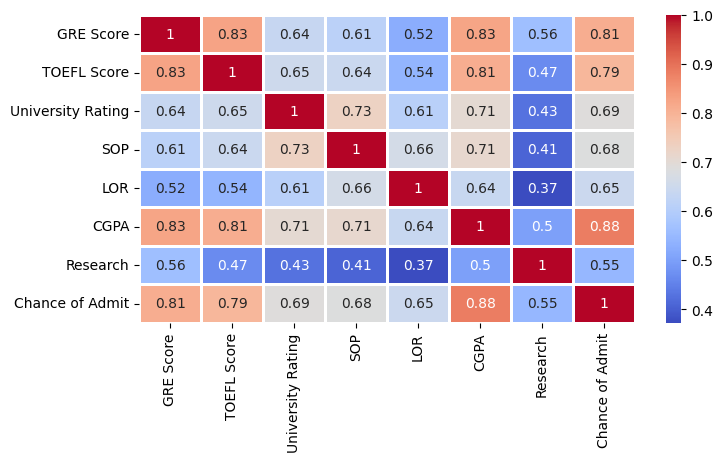

In [26]:
# now checking the correlation between the features using heatmap
plt.figure(figsize=(8,4))
corr = df.corr()
sns.heatmap(corr, linewidths=1, annot=True, cmap='coolwarm')
plt.show()

##### Admission Variables Analysis

Key Points:

- CGPA has the strongest correlation with Chance of Admit (0.88).
- GRE Score (0.81) and TOEFL Score (0.79) are also highly correlated with admission chances.
- University Rating (0.69), SOP (0.68), and LOR (0.65) have moderate impacts.
- Research experience has a smaller, but still positive correlation (0.55).
All variables are positively correlated with the Chance of Admit.

Conclusion:

Focus on improving CGPA, GRE, and TOEFL scores for the best chance of admission. Also, giving attention to university rating, SOP, LOR, and research experience will help improve the overall chances.

#### Feature Engineering

In [27]:
# checking Outliers using IQR
cont_vars = ['GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA', 'Chance of Admit']

for var in cont_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    outliers = df[(df[var]<lower_bound) | (df[var]>upper_bound)]
    
    print(f"{var}: {outliers.shape[0]} outliers")

GRE Score: 0 outliers
TOEFL Score: 0 outliers
SOP: 0 outliers
LOR: 1 outliers
CGPA: 0 outliers
Chance of Admit: 2 outliers


No need to treat outliers, since, it is very less in compared to the dataset

In [28]:
# splitting the data into Target and Features
y = df['Chance of Admit']
X = df.drop('Chance of Admit', axis=1)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [36]:
# Scaling the x_train

from sklearn.preprocessing import StandardScaler

std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_train = pd.DataFrame(X_train_std, columns=X_train.columns)

In [37]:
X_train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,0.389986,0.602418,-0.098298,0.126796,0.564984,0.415018,0.895434
1,-0.066405,0.602418,0.775459,0.633979,1.651491,-0.067852,-1.116777
2,-1.253022,-0.876917,-0.098298,0.126796,-0.521524,-0.134454,-1.116777
3,-0.248961,-0.055064,-0.972054,-0.887570,0.564984,-0.517420,-1.116777
4,-0.796631,-0.219435,-0.098298,0.126796,-1.064777,-0.617324,0.895434


#### Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [39]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(std.transform(X_test))

# Metrics
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression")
print("-----------------")
print(f"R2: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")

Linear Regression
-----------------
R2: 0.8188
RMSE: 0.0609


/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Jamboree/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
# displaying model coefficients with column names
data_lr = list(zip(X_test.columns, lr.coef_))
data_lr = pd.DataFrame(data_lr, columns = ['features', 'coef'])
data_lr

,features,coef
0,GRE Score,0.026671
1,TOEFL Score,0.018226
2,University Rating,0.002940
3,SOP,0.001788
4,LOR,0.015866
5,CGPA,0.067581
6,Research,0.011940


In [42]:
# Lasso Regression
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(std.transform(X_test))
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print("Lasso Regression")
print("----------------")
print(f"R2: {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")

Lasso Regression
----------------
R2: -0.0072
RMSE: 0.1435


/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Jamboree/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [44]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(std.transform(X_test))

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print("Ridge Regression")
print("----------------")
print(f"R2: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")

Ridge Regression
----------------
R2: 0.8188
RMSE: 0.0609


/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Jamboree/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


#### Testing the assumptions of the Linear Regression Model

1) No Multicollinearity

In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(data,col):
    data=data.drop(columns=col,axis=1)
    vif=pd.DataFrame()
    vif['features']=data.columns
    vif['VIF_Value']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif

In [53]:
calculate_vif(x_train,[])

,features,VIF_Value
0,GRE Score,4.489983
1,TOEFL Score,3.664298
2,University Rating,2.572110
3,SOP,2.785764
4,LOR,1.977698
5,CGPA,4.654540
6,Research,1.518065


Considering the threshold of 5 to drop the features, all features are below 5, so we can pass this assumption.

2) Assumption of Linearity

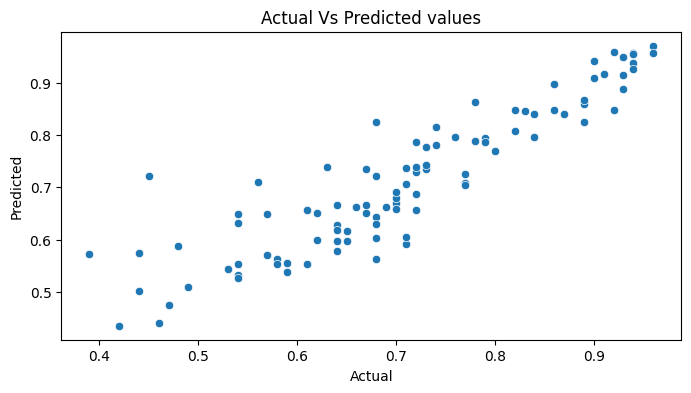

In [55]:
plt.figure(figsize=(8,4))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.title(f"Actual Vs Predicted values")
plt.xlabel(f"Actual")
plt.ylabel(f"Predicted")
plt.show()

3) Test for Homoscedasticity

Since, the spread is random and not in funnel shape, we can say that the Variance of Residuals is constant

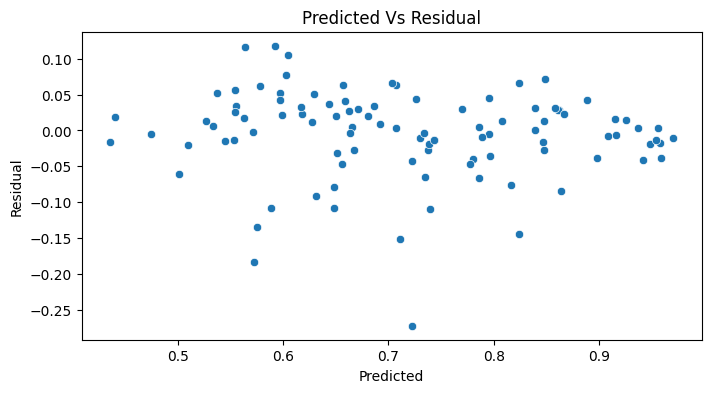

In [56]:
# computing residuals
residual = y_test - y_pred_lr
plt.figure(figsize=(8,4))
sns.scatterplot(x=y_pred_lr, y=residual)
plt.title(f"Predicted Vs Residual")
plt.xlabel(f"Predicted")
plt.ylabel(f"Residual")
plt.show()

4) Normality of Residuals

As we can notice, both the graphs shows that the residual is close to Normally distributed, that means we can pass the assumption.

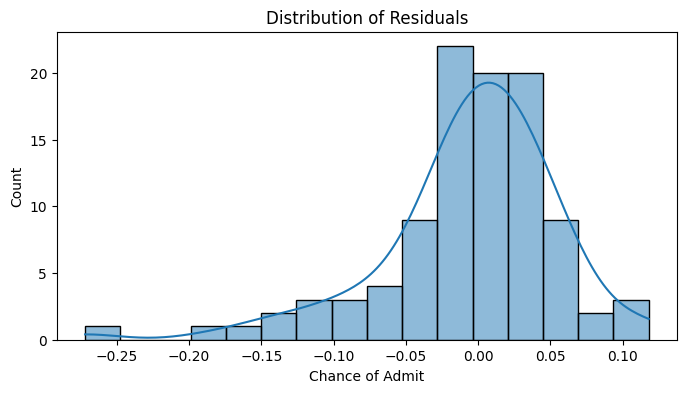

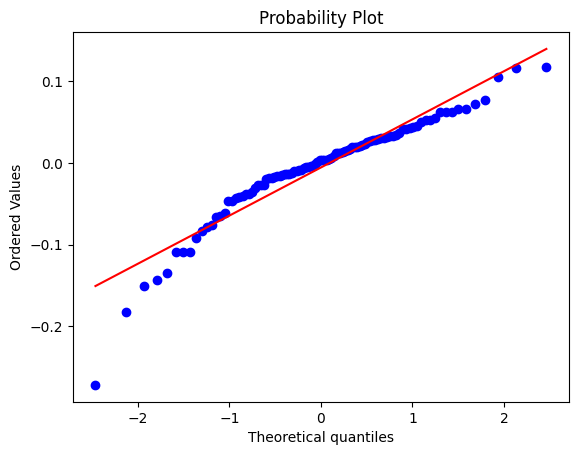

In [57]:
import scipy.stats as stats

# histogram
plt.figure(figsize=(8,4))
sns.histplot(residual, kde=True)
plt.title(f"Distribution of Residuals")
plt.show()

# Q-Q plot
stats.probplot(residual, dist="norm", plot=plt)
plt.show()

5) Mean of Residual close to zero

The mean of residual is almost zero, that means we can also pass this assumption

In [59]:
residual_mean = np.mean(residual)
print("Mean of residuals:", residual_mean)

Mean of residuals: -0.005453623717661251


Feature Recommendations

1. CGPA (Most Important)
- Has the highest impact on admissions.
- Students should focus on improving their grades as it gives the best chances.
    
2. GRE Score
- Plays a strong role, second after CGPA.
- A good GRE score increases the admission probability.
    
3. TOEFL Score
- Also important, but less than GRE and CGPA.
- Students should aim for a solid TOEFL score to support their application.
    
4. LOR (Letter of Recommendation)
- Has a moderate effect.
- Getting strong recommendations from professors or supervisors can help.
    
5. Research
- Research experience adds value.
- Doing projects, papers, or internships can strengthen the profile.
    
6. University Rating
- Has very little influence.
- The rating of the university applied to matters less than personal scores.
    
7. SOP (Statement of Purpose)
- Least important in the model.
- Still useful, but not a major factor compared to CGPA or GRE.

##### Final Suggestion:

- Main focus: Improve CGPA, then prepare well for GRE and TOEFL.
- Extra support: Work on good LORs and some research projects.
- Less priority: SOP and University Rating, but they still add a finishing touch.